In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
iris=load_iris()

In [3]:
X=iris.data
y=iris.target

In [5]:
X_scaled=StandardScaler().fit_transform(X)

In [6]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

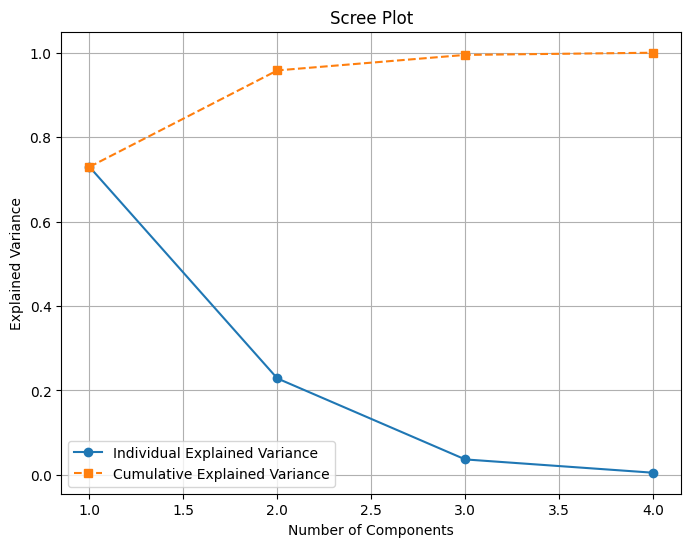

In [7]:
plt.figure(figsize=(8,6))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    'o-',
    label='Individual Explained Variance'
)

# Cumulative explained variance
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    's--',
    label='Cumulative Explained Variance'
)

plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
pca_95=PCA(n_components=0.95)
X_reduced=pca_95.fit_transform(X_scaled)
print(f"Reduced Shape: {X_reduced.shape}")

Reduced Shape: (150, 2)


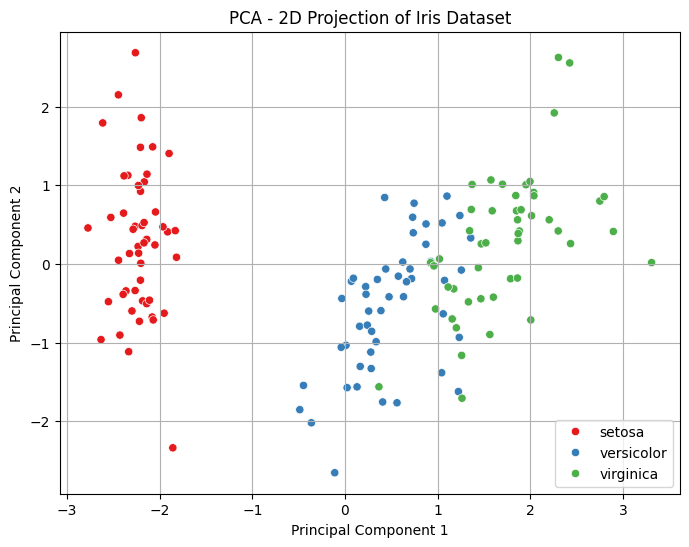

In [10]:
pca_2d=PCA(n_components=2)
X_2d=pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=iris.target_names[y], palette='Set1')
plt.title('PCA - 2D Projection of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()